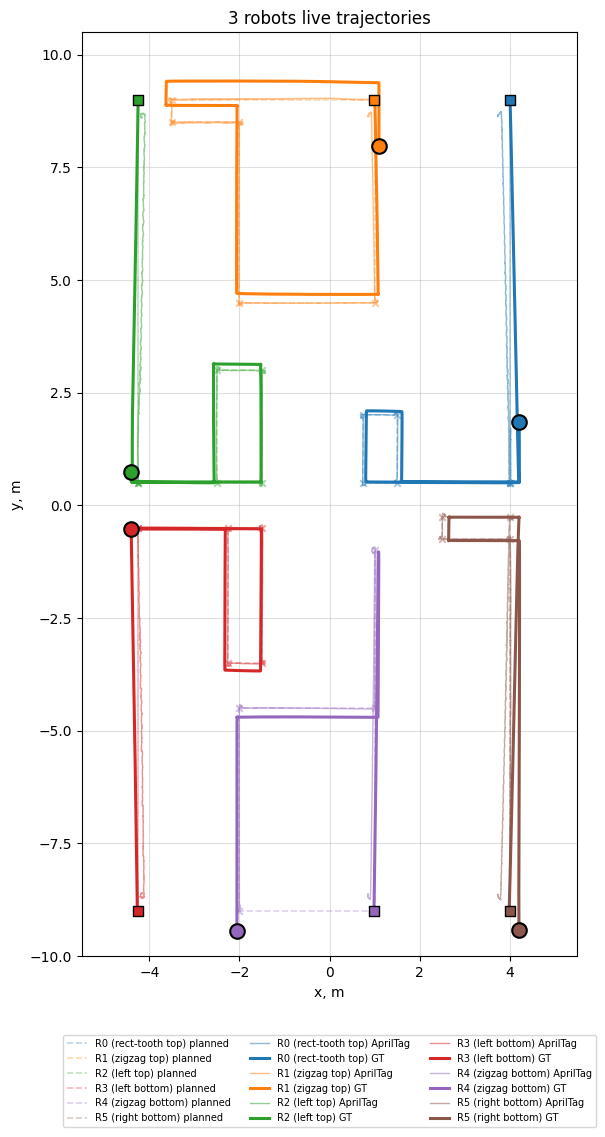

Stopped.


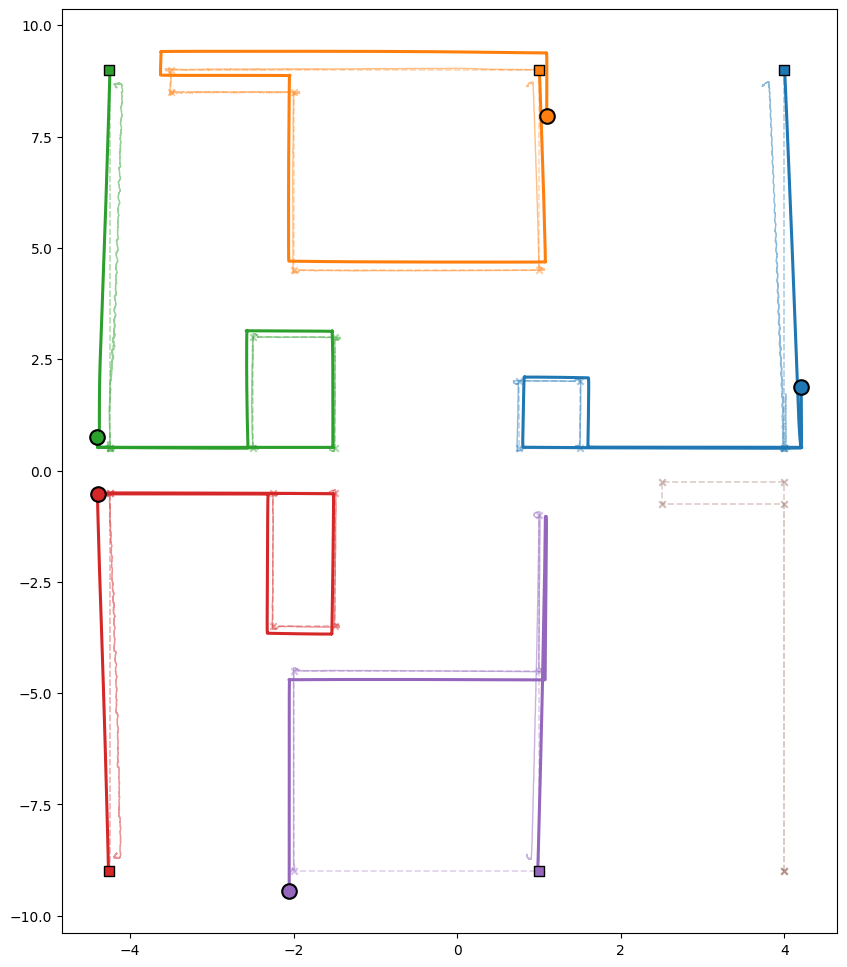

In [1]:
import time
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output


WAYPOINTS = {
    0: [(4.0, 9.0), (4.0, 0.5), (0.75, 0.5), (0.75, 2.0),
        (1.5, 2.0), (1.5, 0.5), (4.0, 0.5), (4.0, 9.0)],
    1: [(1.0, 9.0), (1.0, 4.5), (-2.0, 4.5), (-2.0, 8.5),
        (-3.5, 8.5), (-3.5, 9.0), (1.0, 9.0)],
    2: [(-4.25, 9.0), (-4.25, 0.5), (-1.5, 0.5), (-1.5, 3.0),
        (-2.5, 3.0), (-2.5, 0.5), (-4.25, 0.5), (-4.25, 9.0)],
    3: [(-4.25, -9.0), (-4.25, -0.5), (-1.5, -0.5), (-1.5, -3.5),
        (-2.25, -3.5), (-2.25, -0.5), (-4.25, -0.5), (-4.25, -9.0)],
    4: [(1.0, -9.0), (1.0, -1.0), (1.0, -4.5), (-2.0, -4.5),
        (-2.0, -9.0), (1.0, -9.0)],
    5: [(4.0, -9), (4.0, -0.25),
        (2.5, -0.25), (2.5, -0.75), (4.0, -0.75), (4.0, -9)],
}

ROBOT_COLORS = {
    0: "tab:blue",
    1: "tab:orange",
    2: "tab:green",
    3: "tab:red",
    4: "tab:purple",
    5: "tab:brown",
}

ROBOT_LABELS = {
    0: "R0 (rect-tooth top)",
    1: "R1 (zigzag top)",
    2: "R2 (left top)",
    3: "R3 (left bottom)",
    4: "R4 (zigzag bottom)",
    5: "R5 (right bottom)",
}

LOGS_DIR = Path("/home/katya/wspace/logs")


def find_latest_csvs():
    all_csvs = sorted(LOGS_DIR.glob("multi_robot_*_robot_*.csv"))
    if not all_csvs:
        return {}
    by_ts = {}
    for p in all_csvs:
        parts = p.stem.split("_")
        if len(parts) < 5:
            continue
        try:
            ts = int(parts[2])
            rid = int(parts[4])
        except ValueError:
            continue
        by_ts.setdefault(ts, {})[rid] = p
    return by_ts[max(by_ts.keys())]

try:
    while True:
        csvs = find_latest_csvs()
        fig, ax = plt.subplots(figsize=(10, 12))

        # Planned waypoints (dashed)
        for mid, wps in WAYPOINTS.items():
            wx = [p[0] for p in wps]
            wy = [p[1] for p in wps]
            ax.plot(wx, wy, linestyle="--", color=ROBOT_COLORS[mid],
                    alpha=0.30, linewidth=1.2,
                    label=f"{ROBOT_LABELS[mid]} planned")
            ax.scatter(wx, wy, color=ROBOT_COLORS[mid], alpha=0.4, s=22, marker="x")

        counts = []
        for mid in (0, 1, 2, 3, 4, 5):
            if mid not in csvs:
                counts.append(f"R{mid}=?")
                continue
            try:
                df = pd.read_csv(csvs[mid])
            except Exception:
                counts.append(f"R{mid}=?")
                continue
            if len(df) == 0:
                counts.append(f"R{mid}=0")
                continue


            if "visual_x" in df.columns:
                ap = df[["visual_x", "visual_y"]].to_numpy()
                mask = np.isfinite(ap).all(axis=1)
                ap = ap[mask]
                if len(ap) >= 1:
                    ax.plot(ap[:, 0], ap[:, 1],
                            color=ROBOT_COLORS[mid], linewidth=1.0, alpha=0.5,
                            label=f"{ROBOT_LABELS[mid]} AprilTag")
            n_gt = 0
            if "gt_x" in df.columns:
                gt = df[["gt_x", "gt_y"]].to_numpy()
                mask = np.isfinite(gt).all(axis=1)
                gt = gt[mask]
                n_gt = len(gt)
                if len(gt) >= 1:
                    ax.plot(gt[:, 0], gt[:, 1],
                            color=ROBOT_COLORS[mid], linewidth=2.2,
                            label=f"{ROBOT_LABELS[mid]} GT")
                    ax.scatter([gt[-1, 0]], [gt[-1, 1]],
                               color=ROBOT_COLORS[mid], s=110,
                               edgecolors="black", linewidth=1.5, zorder=5)
                    ax.scatter([gt[0, 0]], [gt[0, 1]],
                               color=ROBOT_COLORS[mid], s=60, marker="s",
                               edgecolors="black", linewidth=1.0, zorder=4)
            counts.append(f"R{mid}={n_gt}")

        ax.set_xlim(-5.5, 5.5)
        ax.set_ylim(-10.0, 10.5)
        ax.set_aspect("equal")
        ax.grid(True, alpha=0.4)
        ax.set_xlabel("x, m")
        ax.set_ylabel("y, m")
        ax.set_title(f"3 robots live trajectories")
        ax.legend(
            loc="upper center",
            bbox_to_anchor=(0.5, -0.08),
            fontsize=7,
            ncol=3
        )

        clear_output(wait=True)
        plt.show()
        time.sleep(0.5)
except KeyboardInterrupt:
    print("Stopped.")

Found CSVs:
  Robot 0: multi_robot_1778503454809702170_robot_0.csv
  Robot 1: multi_robot_1778503454809702170_robot_1.csv
  Robot 2: multi_robot_1778503454809702170_robot_2.csv
  Robot 3: multi_robot_1778503454809702170_robot_3.csv
  Robot 4: multi_robot_1778503454809702170_robot_4.csv
  Robot 5: multi_robot_1778503454809702170_robot_5.csv
  Robot 0: 30379 usable samples
  Robot 1: 30380 usable samples
  Robot 2: 30381 usable samples
  Robot 3: 30383 usable samples
  Robot 4: 30337 usable samples
  Robot 5: 30385 usable samples

Total samples: 182245

=== BEFORE calibration ===
  MAE  x = 11.73 cm, y = 16.33 cm
  RMSE x = 13.46 cm, y = 21.11 cm
  MAX  x = 29.80 cm, y = 53.56 cm
  MAE total = 22.39 cm
  Max total = 56.24 cm


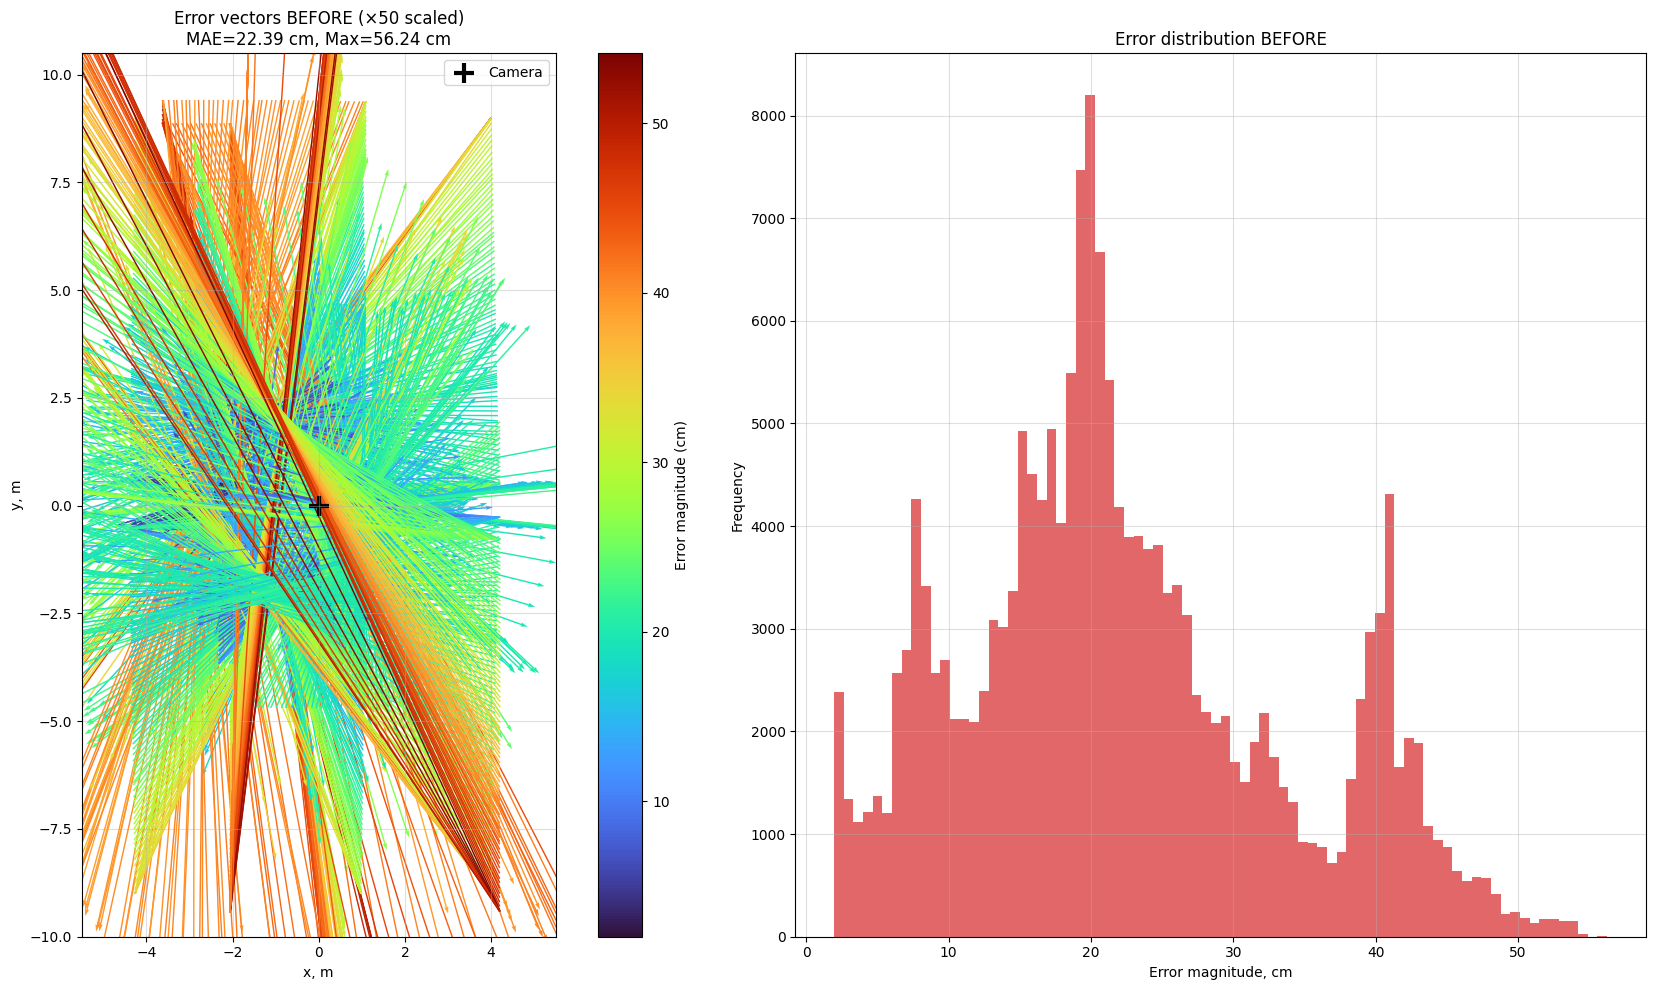


=== Calibration coefficients (12 terms each) ===
error_x = -0.02479*1 -0.04581*x -0.00009*y -0.00004*x^2 -0.00007*x*y -0.00027*y^2 +0.00022*x^3 +0.00003*x^2*y -0.00011*x*y^2 -0.00002*y^3 +0.00010*r^2*x +0.00001*r^2*y
error_y = -0.00172*1 +0.00020*x -0.03810*y +0.00048*x^2 +0.00081*x*y +0.00024*y^2 +0.00003*x^3 +0.00028*x^2*y +0.00003*x*y^2 -0.00017*y^3 +0.00006*r^2*x +0.00011*r^2*y

=== AFTER calibration ===
  MAE  x = 3.09 cm, y = 4.85 cm
  RMSE x = 4.24 cm, y = 5.85 cm
  MAX  x = 11.63 cm, y = 13.73 cm
  MAE total = 6.96 cm
  Max total = 13.75 cm

  Improvement: 3.2x  (in MAE)
               4.1x  (in MAX)


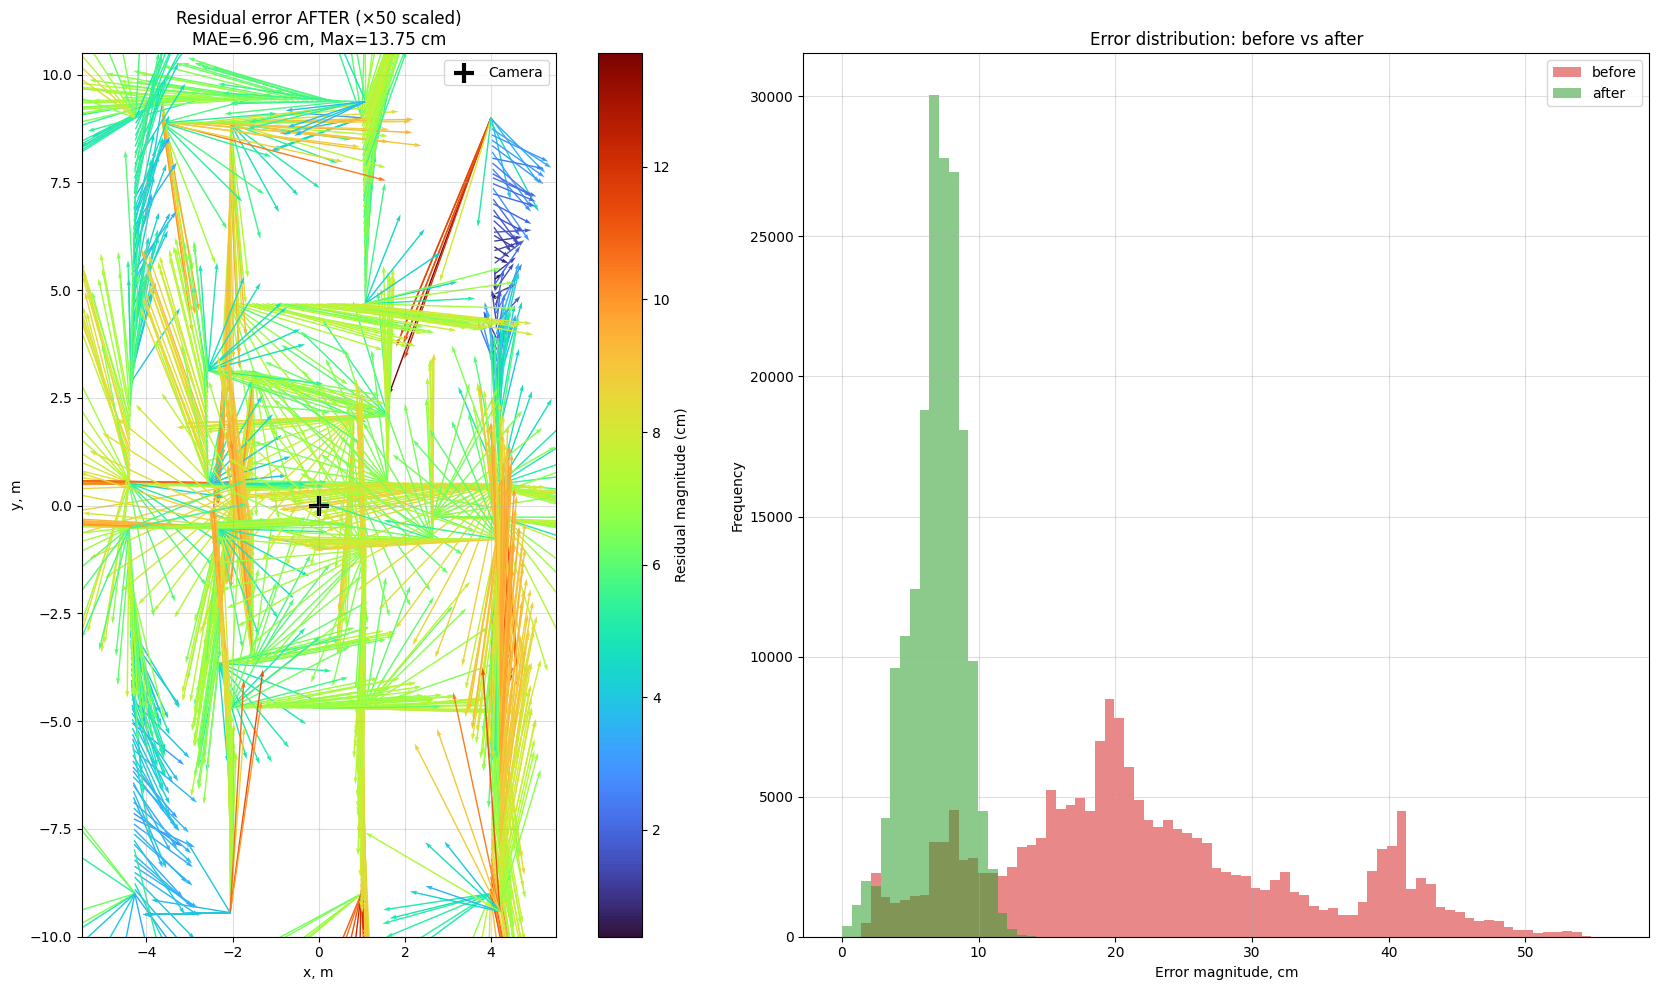


Saved calibration to /home/katya/apriltag_correction.json


In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

LOGS_DIR = Path("/home/katya/wspace/logs")
OUT_JSON = Path.home() / "apriltag_correction.json"


def find_latest_csvs():
    all_csvs = sorted(LOGS_DIR.glob("multi_robot_*_robot_*.csv"))
    by_ts = {}
    for p in all_csvs:
        parts = p.stem.split("_")
        if len(parts) < 5:
            continue
        try:
            ts = int(parts[2])
            rid = int(parts[4])
        except ValueError:
            continue
        by_ts.setdefault(ts, {})[rid] = p
    latest_ts = max(by_ts.keys())
    return by_ts[latest_ts]


def load_paired(csv_path, downsample_to=30000):
    df = pd.read_csv(csv_path)
    df = df.dropna(subset=["visual_x", "visual_y", "gt_x", "gt_y"])
    mask = np.isfinite(df[["visual_x", "visual_y", "gt_x", "gt_y"]]).all(axis=1)
    df = df[mask].reset_index(drop=True)
    if len(df) > downsample_to:
        step = len(df) // downsample_to
        df = df.iloc[::step].reset_index(drop=True)
    return df


# CUBIC basis with radial-distortion terms (12 parameters)
def design(x, y):
    """Cubic + radial: [1, x, y, x², xy, y², x³, x²y, xy², y³, r²x, r²y]"""
    r2 = x*x + y*y
    return np.column_stack([
        np.ones_like(x),
        x, y,
        x*x, x*y, y*y,
        x*x*x, x*x*y, x*y*y, y*y*y,
        r2 * x, r2 * y,
    ])


BASIS_LABELS = ["1", "x", "y", "x^2", "x*y", "y^2",
                "x^3", "x^2*y", "x*y^2", "y^3", "r^2*x", "r^2*y"]


# ---------- Load ----------
csvs = find_latest_csvs()
print("Found CSVs:")
for rid, p in sorted(csvs.items()):
    print(f"  Robot {rid}: {p.name}")

dfs = {rid: load_paired(p) for rid, p in csvs.items()}
for rid, df in dfs.items():
    print(f"  Robot {rid}: {len(df)} usable samples")

all_df = pd.concat(list(dfs.values()), ignore_index=True)
print(f"\nTotal samples: {len(all_df)}")

gx = all_df["gt_x"].to_numpy()
gy = all_df["gt_y"].to_numpy()
vx = all_df["visual_x"].to_numpy()
vy = all_df["visual_y"].to_numpy()

err_x = vx - gx
err_y = vy - gy
err_mag = np.hypot(err_x, err_y)

# ---------- Stats BEFORE ----------
print("\n=== BEFORE calibration ===")
print(f"  MAE  x = {np.mean(np.abs(err_x))*100:.2f} cm, y = {np.mean(np.abs(err_y))*100:.2f} cm")
print(f"  RMSE x = {np.sqrt(np.mean(err_x**2))*100:.2f} cm, y = {np.sqrt(np.mean(err_y**2))*100:.2f} cm")
print(f"  MAX  x = {np.max(np.abs(err_x))*100:.2f} cm, y = {np.max(np.abs(err_y))*100:.2f} cm")
print(f"  MAE total = {np.mean(err_mag)*100:.2f} cm")
print(f"  Max total = {np.max(err_mag)*100:.2f} cm")

mae_total_before = float(np.mean(err_mag))
max_total_before = float(np.max(err_mag))

# ---------- Error map BEFORE ----------
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

step = max(1, len(gx) // 1500)
ax = axes[0]
q = ax.quiver(gx[::step], gy[::step],
              err_x[::step] * 50, err_y[::step] * 50,
              err_mag[::step] * 100,
              scale=1, scale_units='xy', angles='xy',
              cmap='turbo', width=0.003)
plt.colorbar(q, ax=ax, label='Error magnitude (cm)')
ax.set_xlim(-5.5, 5.5)
ax.set_ylim(-10.0, 10.5)
ax.set_aspect("equal")
ax.grid(True, alpha=0.4)
ax.scatter([0], [0], s=200, marker="+", c="black", linewidths=3, label="Camera")
ax.legend()
ax.set_title(f"Error vectors BEFORE (×50 scaled)\n"
             f"MAE={mae_total_before*100:.2f} cm, Max={max_total_before*100:.2f} cm")
ax.set_xlabel("x, m")
ax.set_ylabel("y, m")

ax = axes[1]
ax.hist(err_mag * 100, bins=80, color="tab:red", alpha=0.7)
ax.set_xlabel("Error magnitude, cm")
ax.set_ylabel("Frequency")
ax.set_title("Error distribution BEFORE")
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()


# ---------- Fit cubic model with radial terms ----------
A = design(gx, gy)
coef_x, *_ = np.linalg.lstsq(A, err_x, rcond=None)
coef_y, *_ = np.linalg.lstsq(A, err_y, rcond=None)

print(f"\n=== Calibration coefficients ({len(BASIS_LABELS)} terms each) ===")
print("error_x =", " ".join(f"{c:+.5f}*{b}" for c, b in zip(coef_x, BASIS_LABELS)))
print("error_y =", " ".join(f"{c:+.5f}*{b}" for c, b in zip(coef_y, BASIS_LABELS)))

pred_err_x = A @ coef_x
pred_err_y = A @ coef_y

res_x = err_x - pred_err_x
res_y = err_y - pred_err_y
res_mag = np.hypot(res_x, res_y)

print("\n=== AFTER calibration ===")
print(f"  MAE  x = {np.mean(np.abs(res_x))*100:.2f} cm, y = {np.mean(np.abs(res_y))*100:.2f} cm")
print(f"  RMSE x = {np.sqrt(np.mean(res_x**2))*100:.2f} cm, y = {np.sqrt(np.mean(res_y**2))*100:.2f} cm")
print(f"  MAX  x = {np.max(np.abs(res_x))*100:.2f} cm, y = {np.max(np.abs(res_y))*100:.2f} cm")
print(f"  MAE total = {np.mean(res_mag)*100:.2f} cm")
print(f"  Max total = {np.max(res_mag)*100:.2f} cm")

mae_total_after = float(np.mean(res_mag))
max_total_after = float(np.max(res_mag))

print(f"\n  Improvement: {mae_total_before/mae_total_after:.1f}x  (in MAE)")
print(f"               {max_total_before/max_total_after:.1f}x  (in MAX)")

# ---------- AFTER plot ----------
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

ax = axes[0]
q = ax.quiver(gx[::step], gy[::step],
              res_x[::step] * 50, res_y[::step] * 50,
              res_mag[::step] * 100,
              scale=1, scale_units='xy', angles='xy',
              cmap='turbo', width=0.003)
plt.colorbar(q, ax=ax, label='Residual magnitude (cm)')
ax.set_xlim(-5.5, 5.5)
ax.set_ylim(-10.0, 10.5)
ax.set_aspect("equal")
ax.grid(True, alpha=0.4)
ax.scatter([0], [0], s=200, marker="+", c="black", linewidths=3, label="Camera")
ax.legend()
ax.set_title(f"Residual error AFTER (×50 scaled)\n"
             f"MAE={mae_total_after*100:.2f} cm, Max={max_total_after*100:.2f} cm")
ax.set_xlabel("x, m")
ax.set_ylabel("y, m")

ax = axes[1]
bins = np.linspace(0, max(err_mag.max(), res_mag.max()) * 100, 80)
ax.hist(err_mag * 100, bins=bins, alpha=0.55, color="tab:red", label="before")
ax.hist(res_mag * 100, bins=bins, alpha=0.55, color="tab:green", label="after")
ax.set_xlabel("Error magnitude, cm")
ax.set_ylabel("Frequency")
ax.set_title("Error distribution: before vs after")
ax.legend()
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()


# ---------- Save coefficients ----------
out = {
    "model": "cubic_xy_with_radial",
    "basis": BASIS_LABELS,
    "coef_x": coef_x.tolist(),
    "coef_y": coef_y.tolist(),
    "stats_before": {
        "mae_total_cm": mae_total_before * 100,
        "max_total_cm": max_total_before * 100,
    },
    "stats_after": {
        "mae_total_cm": mae_total_after * 100,
        "max_total_cm": max_total_after * 100,
    },
    "n_samples": int(len(all_df)),
}
OUT_JSON.write_text(json.dumps(out, indent=2))
print(f"\nSaved calibration to {OUT_JSON}")

In [2]:
import json
import numpy as np

# Load the new calibration
with open("/home/katya/apriltag_correction.json") as f:
    cal = json.load(f)

coef_x = np.array(cal["coef_x"])
coef_y = np.array(cal["coef_y"])

def design(x, y):
    r2 = x*x + y*y
    return np.array([1, x, y, x*x, x*y, y*y,
                     x*x*x, x*x*y, x*y*y, y*y*y,
                     r2*x, r2*y])

# Test predicted correction at various points
test_points = [
    (4, 9),   "верхний правый угол",
    (-4, 9),  "верхний левый угол",
    (0, 0),   "центр",
    (4, -9),  "нижний правый угол",
    (-4, -9), "нижний левый угол",
    (0, -8),  "низ центр",
]

print(f"{'Point':<20} {'corr_x (cm)':>12} {'corr_y (cm)':>12}")
print("-" * 50)
for i in range(0, len(test_points), 2):
    x, y = test_points[i]
    label = test_points[i+1]
    phi = design(x, y)
    err_x_pred = float(phi @ coef_x) * 100  # in cm
    err_y_pred = float(phi @ coef_y) * 100
    print(f"({x:+.1f}, {y:+.1f}) {label:<10} {err_x_pred:>12.2f} {err_y_pred:>12.2f}")

print(f"\nИспользовано сэмплов: {cal['n_samples']}")
print(f"MAE до: {cal['stats_before']['mae_total_cm']:.2f} см")
print(f"MAE после: {cal['stats_after']['mae_total_cm']:.2f} см")

Point                 corr_x (cm)  corr_y (cm)
--------------------------------------------------
(+4.0, +9.0) верхний правый угол       -21.66       -24.00
(-4.0, +9.0) верхний левый угол        12.00       -37.05
(+0.0, +0.0) центр             -2.48        -0.17
(+4.0, -9.0) нижний правый угол       -20.98        36.25
(-4.0, -9.0) нижний левый угол        11.61        34.91
(+0.0, -8.0) низ центр         -3.68        34.85

Использовано сэмплов: 182245
MAE до: 22.39 см
MAE после: 6.96 см


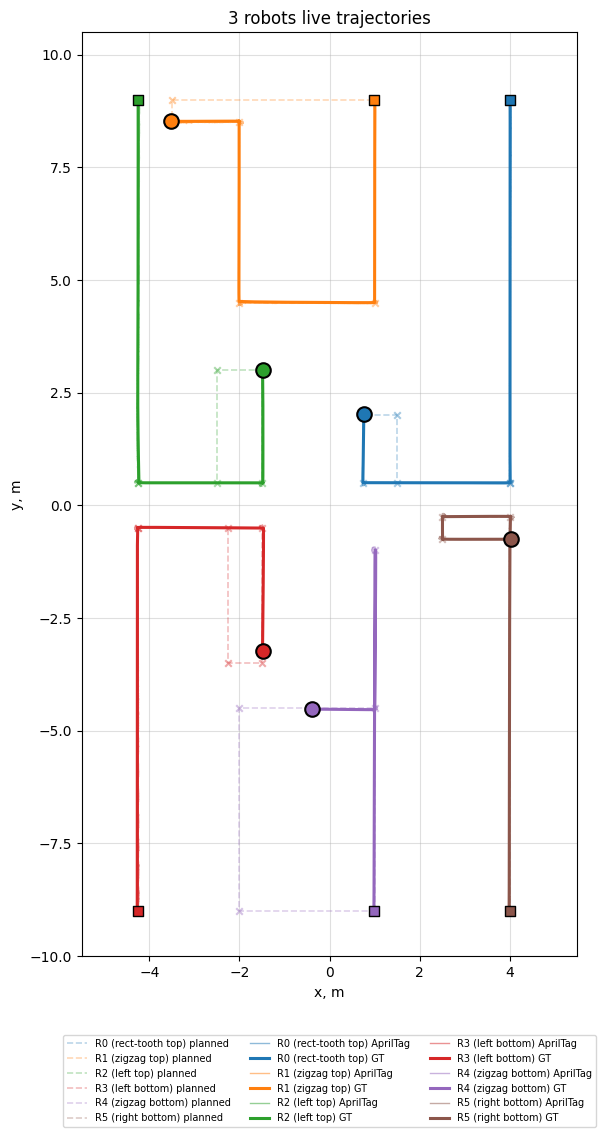

Stopped.


In [3]:
import time
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output


WAYPOINTS = {
    0: [(4.0, 9.0), (4.0, 0.5), (0.75, 0.5), (0.75, 2.0),
        (1.5, 2.0), (1.5, 0.5), (4.0, 0.5), (4.0, 9.0)],
    1: [(1.0, 9.0), (1.0, 4.5), (-2.0, 4.5), (-2.0, 8.5),
        (-3.5, 8.5), (-3.5, 9.0), (1.0, 9.0)],
    2: [(-4.25, 9.0), (-4.25, 0.5), (-1.5, 0.5), (-1.5, 3.0),
        (-2.5, 3.0), (-2.5, 0.5), (-4.25, 0.5), (-4.25, 9.0)],
    3: [(-4.25, -9.0), (-4.25, -0.5), (-1.5, -0.5), (-1.5, -3.5),
        (-2.25, -3.5), (-2.25, -0.5), (-4.25, -0.5), (-4.25, -9.0)],
    4: [(1.0, -9.0), (1.0, -1.0), (1.0, -4.5), (-2.0, -4.5),
        (-2.0, -9.0), (1.0, -9.0)],
    5: [(4.0, -9), (4.0, -0.25),
        (2.5, -0.25), (2.5, -0.75), (4.0, -0.75), (4.0, -9)],
}

ROBOT_COLORS = {
    0: "tab:blue",
    1: "tab:orange",
    2: "tab:green",
    3: "tab:red",
    4: "tab:purple",
    5: "tab:brown",
}

ROBOT_LABELS = {
    0: "R0 (rect-tooth top)",
    1: "R1 (zigzag top)",
    2: "R2 (left top)",
    3: "R3 (left bottom)",
    4: "R4 (zigzag bottom)",
    5: "R5 (right bottom)",
}

LOGS_DIR = Path("/home/katya/wspace/logs")


def find_latest_csvs():
    all_csvs = sorted(LOGS_DIR.glob("multi_robot_*_robot_*.csv"))
    if not all_csvs:
        return {}
    by_ts = {}
    for p in all_csvs:
        parts = p.stem.split("_")
        if len(parts) < 5:
            continue
        try:
            ts = int(parts[2])
            rid = int(parts[4])
        except ValueError:
            continue
        by_ts.setdefault(ts, {})[rid] = p
    return by_ts[max(by_ts.keys())]

try:
    while True:
        csvs = find_latest_csvs()
        fig, ax = plt.subplots(figsize=(10, 12))

        # Planned waypoints (dashed)
        for mid, wps in WAYPOINTS.items():
            wx = [p[0] for p in wps]
            wy = [p[1] for p in wps]
            ax.plot(wx, wy, linestyle="--", color=ROBOT_COLORS[mid],
                    alpha=0.30, linewidth=1.2,
                    label=f"{ROBOT_LABELS[mid]} planned")
            ax.scatter(wx, wy, color=ROBOT_COLORS[mid], alpha=0.4, s=22, marker="x")

        counts = []
        for mid in (0, 1, 2, 3, 4, 5):
            if mid not in csvs:
                counts.append(f"R{mid}=?")
                continue
            try:
                df = pd.read_csv(csvs[mid])
            except Exception:
                counts.append(f"R{mid}=?")
                continue
            if len(df) == 0:
                counts.append(f"R{mid}=0")
                continue


            if "visual_x" in df.columns:
                ap = df[["visual_x", "visual_y"]].to_numpy()
                mask = np.isfinite(ap).all(axis=1)
                ap = ap[mask]
                if len(ap) >= 1:
                    ax.plot(ap[:, 0], ap[:, 1],
                            color=ROBOT_COLORS[mid], linewidth=1.0, alpha=0.5,
                            label=f"{ROBOT_LABELS[mid]} AprilTag")
            n_gt = 0
            if "gt_x" in df.columns:
                gt = df[["gt_x", "gt_y"]].to_numpy()
                mask = np.isfinite(gt).all(axis=1)
                gt = gt[mask]
                n_gt = len(gt)
                if len(gt) >= 1:
                    ax.plot(gt[:, 0], gt[:, 1],
                            color=ROBOT_COLORS[mid], linewidth=2.2,
                            label=f"{ROBOT_LABELS[mid]} GT")
                    ax.scatter([gt[-1, 0]], [gt[-1, 1]],
                               color=ROBOT_COLORS[mid], s=110,
                               edgecolors="black", linewidth=1.5, zorder=5)
                    ax.scatter([gt[0, 0]], [gt[0, 1]],
                               color=ROBOT_COLORS[mid], s=60, marker="s",
                               edgecolors="black", linewidth=1.0, zorder=4)
            counts.append(f"R{mid}={n_gt}")

        ax.set_xlim(-5.5, 5.5)
        ax.set_ylim(-10.0, 10.5)
        ax.set_aspect("equal")
        ax.grid(True, alpha=0.4)
        ax.set_xlabel("x, m")
        ax.set_ylabel("y, m")
        ax.set_title(f"3 robots live trajectories")
        ax.legend(
            loc="upper center",
            bbox_to_anchor=(0.5, -0.08),
            fontsize=7,
            ncol=3
        )

        clear_output(wait=True)
        plt.show()
        time.sleep(0.5)
except KeyboardInterrupt:
    print("Stopped.")

In [1]:
from pathlib import Path
LOGS_DIR = Path("/home/katya/wspace/logs")
csvs = sorted(LOGS_DIR.glob("multi_robot_*_robot_*.csv"))
print(f"Found {len(csvs)} CSV files:")
for p in csvs[-10:]:
    print(f"  {p.name}")

Found 6 CSV files:
  multi_robot_1778510917912339808_robot_0.csv
  multi_robot_1778510917912339808_robot_1.csv
  multi_robot_1778510917912339808_robot_2.csv
  multi_robot_1778510917912339808_robot_3.csv
  multi_robot_1778510917912339808_robot_4.csv
  multi_robot_1778510917912339808_robot_5.csv


In [2]:
import json
import numpy as np
import pandas as pd

LOGS_DIR = Path("/home/katya/wspace/logs")
OUT_JSON = Path.home() / "kt_metrics_report.json"


# Trajectories from controller setup (same as in plot cell)
WAYPOINTS = {
    0: [(4.0, 9.0), (4.0, 0.5), (0.75, 0.5), (0.75, 2.0),
        (1.5, 2.0), (1.5, 0.5), (4.0, 0.5), (4.0, 9.0)],
    1: [(1.0, 9.0), (1.0, 4.5), (-2.0, 4.5), (-2.0, 8.5),
        (-3.5, 8.5), (-3.5, 9.0), (1.0, 9.0)],
    2: [(-4.25, 9.0), (-4.25, 0.5), (-1.5, 0.5), (-1.5, 3.0),
        (-2.5, 3.0), (-2.5, 0.5), (-4.25, 0.5), (-4.25, 9.0)],
    3: [(-4.25, -9.0), (-4.25, -0.5), (-1.5, -0.5), (-1.5, -3.5),
        (-2.25, -3.5), (-2.25, -0.5), (-4.25, -0.5), (-4.25, -9.0)],
    4: [(1.0, -9.0), (1.0, -1.0), (1.0, -4.5), (-2.0, -4.5),
        (-2.0, -9.0), (1.0, -9.0)],
    5: [(4.0, -9.0), (4.0, -0.25), (2.5, -0.25), (2.5, -0.75),
        (4.0, -0.75), (4.0, -9.0)],
}


def find_latest_csvs():
    all_csvs = sorted(LOGS_DIR.glob("multi_robot_*_robot_*.csv"))
    by_ts = {}
    for p in all_csvs:
        parts = p.stem.split("_")
        if len(parts) < 5:
            continue
        try:
            ts = int(parts[2]); rid = int(parts[4])
        except ValueError:
            continue
        by_ts.setdefault(ts, {})[rid] = p
    return by_ts[max(by_ts.keys())]


def wrap_to_pi(a):
    return (a + np.pi) % (2.0 * np.pi) - np.pi


def trajectory_length(wps):
    """Total length of waypoint sequence in metres."""
    L = 0.0
    for i in range(len(wps) - 1):
        x0, y0 = wps[i]; x1, y1 = wps[i + 1]
        L += np.hypot(x1 - x0, y1 - y0)
    return L


# ---------- LOAD ----------
csvs = find_latest_csvs()
print(f"Found CSVs: {len(csvs)} robots\n")

report = {"per_robot": {}, "aggregate": {}}
all_eT = []
all_eR_deg = []
all_recall_pct = []
all_visual_fps = []
all_gt_fps = []
all_max_gap_s = []
all_durations = []

for rid in sorted(csvs):
    df = pd.read_csv(csvs[rid])
    n_total = len(df)
    n_visual = df["source"].eq("visual").sum() if "source" in df else 0
    n_gt = df["source"].eq("gt").sum() if "source" in df else 0

    # ---- Sync paired samples ----
    paired = df.dropna(subset=["visual_x", "visual_y", "gt_x", "gt_y"]).reset_index(drop=True)
    n_paired = len(paired)
    if n_paired == 0:
        print(f"Robot {rid}: no paired samples, skipping")
        continue

    # ---- Translational error eT (m) ----
    err_x = paired["visual_x"].to_numpy() - paired["gt_x"].to_numpy()
    err_y = paired["visual_y"].to_numpy() - paired["gt_y"].to_numpy()
    eT = np.hypot(err_x, err_y)
    mae_eT = float(np.mean(eT))
    rmse_eT = float(np.sqrt(np.mean(eT ** 2)))
    max_eT = float(np.max(eT))
    p95_eT = float(np.percentile(eT, 95))

    # ---- Rotational error eR (deg) ----
    if "visual_yaw" in paired and "gt_yaw" in paired:
        yaw_v = paired["visual_yaw"].to_numpy()
        yaw_gt = paired["gt_yaw"].to_numpy()
        eR = np.abs(wrap_to_pi(yaw_v - yaw_gt))
        eR_deg = np.rad2deg(eR)
        mae_eR_deg = float(np.mean(eR_deg))
        rmse_eR_deg = float(np.sqrt(np.mean(eR_deg ** 2)))
        max_eR_deg = float(np.max(eR_deg))
    else:
        mae_eR_deg = rmse_eR_deg = max_eR_deg = float("nan")

    # ---- Visual FPS (Hz) and gaps ----
    # Use rows where source=visual to compute publish rate.
    v_only = df[df["source"] == "visual"].reset_index(drop=True) if "source" in df else df.iloc[:0]
    duration_s = 0.0
    visual_fps = float("nan")
    max_gap_s = float("nan")
    if len(v_only) > 10 and "t" in v_only:
        t = v_only["t"].to_numpy()
        duration_s = float(t[-1] - t[0])
        if duration_s > 0:
            visual_fps = len(v_only) / duration_s
        dt = np.diff(t)
        max_gap_s = float(np.max(dt)) if len(dt) else float("nan")

    # ---- GT FPS ----
    g_only = df[df["source"] == "gt"].reset_index(drop=True) if "source" in df else df.iloc[:0]
    gt_fps = float("nan")
    if len(g_only) > 10 and "t" in g_only:
        t = g_only["t"].to_numpy()
        d = float(t[-1] - t[0])
        if d > 0:
            gt_fps = len(g_only) / d

    # ---- Recall: doля времени где AprilTag видит маркер ----
    # Detection considered "lost" if visual hasn't updated for >0.2 s
    DETECTION_LOST_THRESHOLD = 0.2  # s
    recall_pct = 100.0
    if len(v_only) > 10 and "t" in v_only:
        dt = np.diff(v_only["t"].to_numpy())
        lost_time = np.sum(dt[dt > DETECTION_LOST_THRESHOLD])
        recall_pct = max(0.0, 100.0 * (1.0 - lost_time / duration_s)) if duration_s > 0 else 100.0

    # ---- Distance travelled (GT) ----
    gt_pos = paired[["gt_x", "gt_y"]].to_numpy()
    d_travelled = float(np.sum(np.hypot(np.diff(gt_pos[:, 0]), np.diff(gt_pos[:, 1]))))

    # Planned trajectory length per loop
    L_per_loop = trajectory_length(WAYPOINTS[rid]) if rid in WAYPOINTS else float("nan")
    n_loops_done = d_travelled / L_per_loop if L_per_loop and L_per_loop > 0 else float("nan")

    rrec = {
        "samples_total": int(n_total),
        "samples_visual": int(n_visual),
        "samples_gt": int(n_gt),
        "samples_paired": int(n_paired),
        "duration_s": round(duration_s, 1),
        "distance_travelled_m": round(d_travelled, 1),
        "planned_loop_length_m": round(L_per_loop, 1) if not np.isnan(L_per_loop) else None,
        "loops_completed_approx": round(n_loops_done, 2) if not np.isnan(n_loops_done) else None,
        "visual_fps_avg": round(visual_fps, 1) if not np.isnan(visual_fps) else None,
        "gt_fps_avg": round(gt_fps, 1) if not np.isnan(gt_fps) else None,
        "detection_recall_pct": round(recall_pct, 2),
        "max_detection_gap_s": round(max_gap_s, 2) if not np.isnan(max_gap_s) else None,
        "eT_mae_cm": round(mae_eT * 100, 2),
        "eT_rmse_cm": round(rmse_eT * 100, 2),
        "eT_max_cm": round(max_eT * 100, 2),
        "eT_p95_cm": round(p95_eT * 100, 2),
        "eR_mae_deg": round(mae_eR_deg, 3),
        "eR_rmse_deg": round(rmse_eR_deg, 3),
        "eR_max_deg": round(max_eR_deg, 3),
    }
    report["per_robot"][rid] = rrec

    all_eT.append(eT)
    if not np.isnan(mae_eR_deg):
        all_eR_deg.append(eR_deg)
    all_recall_pct.append(recall_pct)
    if not np.isnan(visual_fps):
        all_visual_fps.append(visual_fps)
    if not np.isnan(gt_fps):
        all_gt_fps.append(gt_fps)
    if not np.isnan(max_gap_s):
        all_max_gap_s.append(max_gap_s)
    all_durations.append(duration_s)

# ---------- AGGREGATE ----------
eT_all = np.concatenate(all_eT) if all_eT else np.array([])
eR_all = np.concatenate(all_eR_deg) if all_eR_deg else np.array([])

agg = {
    "n_robots": len(report["per_robot"]),
    "total_paired_samples": int(sum(r["samples_paired"] for r in report["per_robot"].values())),
    "total_experiment_duration_s": round(float(np.max(all_durations)) if all_durations else 0, 1),
    "total_distance_travelled_m": round(
        float(sum(r["distance_travelled_m"] for r in report["per_robot"].values())), 1
    ),
    "eT_mae_cm": round(float(np.mean(eT_all)) * 100, 2) if len(eT_all) else None,
    "eT_rmse_cm": round(float(np.sqrt(np.mean(eT_all ** 2))) * 100, 2) if len(eT_all) else None,
    "eT_max_cm": round(float(np.max(eT_all)) * 100, 2) if len(eT_all) else None,
    "eT_p95_cm": round(float(np.percentile(eT_all, 95)) * 100, 2) if len(eT_all) else None,
    "eR_mae_deg": round(float(np.mean(eR_all)), 3) if len(eR_all) else None,
    "eR_rmse_deg": round(float(np.sqrt(np.mean(eR_all ** 2))), 3) if len(eR_all) else None,
    "eR_max_deg": round(float(np.max(eR_all)), 3) if len(eR_all) else None,
    "detection_recall_pct_avg": round(float(np.mean(all_recall_pct)), 2) if all_recall_pct else None,
    "visual_fps_avg": round(float(np.mean(all_visual_fps)), 1) if all_visual_fps else None,
    "gt_fps_avg": round(float(np.mean(all_gt_fps)), 1) if all_gt_fps else None,
    "max_detection_gap_s": round(float(np.max(all_max_gap_s)), 2) if all_max_gap_s else None,
}
report["aggregate"] = agg

# ---------- PRINT ----------
print("=" * 72)
print(" PER-ROBOT METRICS")
print("=" * 72)
header = (f"{'R':>2} {'paired':>8} {'dur,s':>7} {'dist,m':>7} {'loops':>6} "
          f"{'recall%':>8} {'FPS':>5} {'MAE,cm':>7} {'p95,cm':>7} {'Max,cm':>7} "
          f"{'MAE°':>6} {'Max°':>6}")
print(header)
print("-" * 72)
for rid, r in sorted(report["per_robot"].items()):
    print(f"{rid:>2} {r['samples_paired']:>8} {r['duration_s']:>7.1f} "
          f"{r['distance_travelled_m']:>7.1f} {r['loops_completed_approx'] or 0:>6.2f} "
          f"{r['detection_recall_pct']:>8.2f} {r['visual_fps_avg'] or 0:>5.1f} "
          f"{r['eT_mae_cm']:>7.2f} {r['eT_p95_cm']:>7.2f} {r['eT_max_cm']:>7.2f} "
          f"{r['eR_mae_deg']:>6.2f} {r['eR_max_deg']:>6.2f}")

print()
print("=" * 72)
print(" AGGREGATE METRICS (all robots combined)")
print("=" * 72)
print(f"  Robots tracked simultaneously:     {agg['n_robots']}")
print(f"  Total paired samples:              {agg['total_paired_samples']:,}")
print(f"  Experiment duration:               {agg['total_experiment_duration_s']:.0f} s "
      f"({agg['total_experiment_duration_s']/60:.1f} min)")
print(f"  Total distance travelled (all):    {agg['total_distance_travelled_m']:.1f} m")
print()
print(f"  Translational error (eT):")
print(f"    MAE:                             {agg['eT_mae_cm']:.2f} cm")
print(f"    RMSE:                            {agg['eT_rmse_cm']:.2f} cm")
print(f"    95th percentile:                 {agg['eT_p95_cm']:.2f} cm")
print(f"    Max:                             {agg['eT_max_cm']:.2f} cm")
print()
print(f"  Rotational error (eR):")
print(f"    MAE:                             {agg['eR_mae_deg']:.2f}°")
print(f"    RMSE:                            {agg['eR_rmse_deg']:.2f}°")
print(f"    Max:                             {agg['eR_max_deg']:.2f}°")
print()
print(f"  Detection performance:")
print(f"    Avg recall:                      {agg['detection_recall_pct_avg']:.2f}%")
print(f"    Max gap between detections:      {agg['max_detection_gap_s']:.2f} s")
print()
print(f"  Throughput:")
print(f"    AprilTag visual stream avg FPS:  {agg['visual_fps_avg']:.1f} Hz per robot")
print(f"    Ground-truth stream avg FPS:     {agg['gt_fps_avg']:.1f} Hz per robot")

# ---------- SAVE ----------
OUT_JSON.write_text(json.dumps(report, indent=2, ensure_ascii=False))
print(f"\nSaved full report to: {OUT_JSON}")

Found CSVs: 6 robots

 PER-ROBOT METRICS
 R   paired   dur,s  dist,m  loops  recall%   FPS  MAE,cm  p95,cm  Max,cm   MAE°   Max°
------------------------------------------------------------------------
 0    43581  1233.3     2.8   0.10     0.32   0.7    3.67   11.69   13.78   0.40   3.50
 1    43584  1235.0     2.8   0.15     0.31   0.7    5.12    6.26    7.80   0.41   3.32
 2    43586  1235.0     2.7   0.10     0.33   0.7    3.94    7.03    7.99   0.43   3.26
 3    43588  1235.0     2.6   0.09     0.33   0.7    3.72    7.51    9.46   0.35   2.98
 4    43591  1235.0     2.6   0.12     0.34   0.7    8.45   10.48   11.43   0.37   3.35
 5    43593  1235.0     2.5   0.12     0.34   0.7    6.68    8.62   10.40   0.33   3.47

 AGGREGATE METRICS (all robots combined)
  Robots tracked simultaneously:     6
  Total paired samples:              261,523
  Experiment duration:               1235 s (20.6 min)
  Total distance travelled (all):    16.0 m

  Translational error (eT):
    MAE:        